# Milestone 1: Week 1 & 2 - Requirements & Dataset Preparation

## Task 1: Define project scope and success metrics.

In [3]:
!pip install pandas

## Task 2: Load the Netflix Kaggle dataset.

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.shape

(8807, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Task 3: Clean the dataset

In [10]:
#check for nulls
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
# Percentage of missing values
(df.isnull().sum()/len(df))*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [12]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
#check for inconsistent categories
df.select_dtypes(include='object').columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
df['country'].unique()

array(['United States', 'South Africa', nan, 'India',
       'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
       'United Kingdom', 'Germany, Czech Republic', 'Mexico', 'Turkey',
       'Australia', 'United States, India, France', 'Finland',
       'China, Canada, United States',
       'South Africa, United States, Japan', 'Nigeria', 'Japan',
       'Spain, United States', 'France', 'Belgium',
       'United Kingdom, United States', 'United States, United Kingdom',
       'France, United States', 'South Korea', 'Spain',
       'United States, Singapore', 'United Kingdom, Australia, France',
       'United Kingdom, Australia, France, United States',
       'United States, Canada', 'Germany, United States',
       'South Africa, United States', 'United States, Mexico',
       'United States, Italy, France, Japan',
       'United States, Italy, Romania, United Kingdom',
       'Australia, United States', 'Argentina, Venezuela',
       'United States, United Kin

In [15]:
df['country'].value_counts()

country
United States                                    2818
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64

In [16]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Not Available')

In [17]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df['date_added'] = df['date_added'].fillna("unknown")
df['rating'] = df['rating'].fillna("not rated")
df['duration'] = df['duration'].fillna("unknown")

In [20]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

## Task 4: Normalize categorical features such as genre, rating, and country.

In [23]:
df.select_dtypes(include='object').columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [24]:
df = df.fillna("unknown")

In [25]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [26]:
df['rating'].value_counts()

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
not rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64

In [27]:
df[df['rating'].str.contains('MIN')]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [28]:
df.loc[df['rating'].str.contains('MIN'), 'duration'] = df['rating']

In [29]:
import numpy as np

df.loc[df['rating'].str.contains('MIN'), 'rating'] = np.nan

In [30]:
df['rating'].value_counts()

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
not rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64

In [31]:
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

C:\Users\daayu\AppData\Local\Temp\ipykernel_16928\2284108631.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].mode()[0], inplace=True)


In [32]:
df['rating'].isnull().sum()

np.int64(0)

In [33]:
df['release_year'] = df['release_year'].astype(str)

In [34]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['release_year'] = pd.to_datetime(df['release_year'], format='%Y')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   datetime64[ns]
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](2), object(10)
memory usage: 825.8+ KB


In [36]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020-01-01,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021-01-01,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021-01-01,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Not Available,2021-09-24,2021-01-01,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021-01-01,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [37]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [38]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower()

In [39]:
df['rating'] = df['rating'].replace({
    'tv-ma': 'TV-MA',
    'tv ma': 'TV-MA',
    'tv-14': 'TV-14'
})

In [40]:
df['rating'].unique()

array(['pg-13', 'TV-MA', 'pg', 'TV-14', 'tv-pg', 'tv-y', 'tv-y7', 'r',
       'tv-g', 'g', 'nc-17', '74 min', '84 min', '66 min', 'nr',
       'not rated', 'tv-y7-fv', 'ur'], dtype=object)

In [41]:
df['duration_number'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [42]:
df['duration_type'] = df['duration'].str.extract('([a-zA-Z]+)')

In [43]:
df['duration_type'] = df['duration_type'].replace({
    'seasons':'season'
})

In [44]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_number,duration_type
0,s1,movie,dick johnson is dead,kirsten johnson,unknown,united states,2021-09-25,2020-01-01,pg-13,90 min,documentaries,"as her father nears the end of his life, filmm...",90.0,min
1,s2,tv show,blood & water,unknown,"ama qamata, khosi ngema, gail mabalane, thaban...",south africa,2021-09-24,2021-01-01,TV-MA,2 seasons,"international tv shows, tv dramas, tv mysteries","after crossing paths at a party, a cape town t...",2.0,season
2,s3,tv show,ganglands,julien leclercq,"sami bouajila, tracy gotoas, samuel jouy, nabi...",not available,2021-09-24,2021-01-01,TV-MA,1 season,"crime tv shows, international tv shows, tv act...",to protect his family from a powerful drug lor...,1.0,season
3,s4,tv show,jailbirds new orleans,unknown,unknown,not available,2021-09-24,2021-01-01,TV-MA,1 season,"docuseries, reality tv","feuds, flirtations and toilet talk go down amo...",1.0,season
4,s5,tv show,kota factory,unknown,"mayur more, jitendra kumar, ranjan raj, alam k...",india,2021-09-24,2021-01-01,TV-MA,2 seasons,"international tv shows, romantic tv shows, tv ...",in a city of coaching centers known to train i...,2.0,season


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8807 non-null   object        
 1   type             8807 non-null   object        
 2   title            8807 non-null   object        
 3   director         8807 non-null   object        
 4   cast             8807 non-null   object        
 5   country          8807 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8807 non-null   datetime64[ns]
 8   rating           8807 non-null   object        
 9   duration         8807 non-null   object        
 10  listed_in        8807 non-null   object        
 11  description      8807 non-null   object        
 12  duration_number  8804 non-null   float64       
 13  duration_type    8807 non-null   object        
dtypes: datetime64[ns](2), float64(1), object

In [46]:
df['type'] = df['type'].str.title()
df['title'] = df['title'].str.title()
df['director'] = df['director'].str.title()
df['cast'] = df['cast'].str.title()
df['country'] = df['country'].str.title()
df['rating'] = df['rating'].str.upper()
df['listed_in'] = df['listed_in'].str.title()

In [47]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_number,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020-01-01,PG-13,90 min,Documentaries,"as her father nears the end of his life, filmm...",90.0,min
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021-01-01,TV-MA,2 seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","after crossing paths at a party, a cape town t...",2.0,season
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021-01-01,TV-MA,1 season,"Crime Tv Shows, International Tv Shows, Tv Act...",to protect his family from a powerful drug lor...,1.0,season
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Not Available,2021-09-24,2021-01-01,TV-MA,1 season,"Docuseries, Reality Tv","feuds, flirtations and toilet talk go down amo...",1.0,season
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021-01-01,TV-MA,2 seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",in a city of coaching centers known to train i...,2.0,season


# Milestone 2: Week 3 & 4 - EDA & Feature Engineering

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Analyze Netflix content growth over time.

In [51]:
cols = ['date_added', 'release_year']
df[cols] = df[cols].apply(pd.to_datetime, errors='coerce')

In [97]:
df['year_added'] = df['date_added'].dt.year

In [99]:
content_growth = df['year_added'].value_counts().sort_index()
content_growth

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

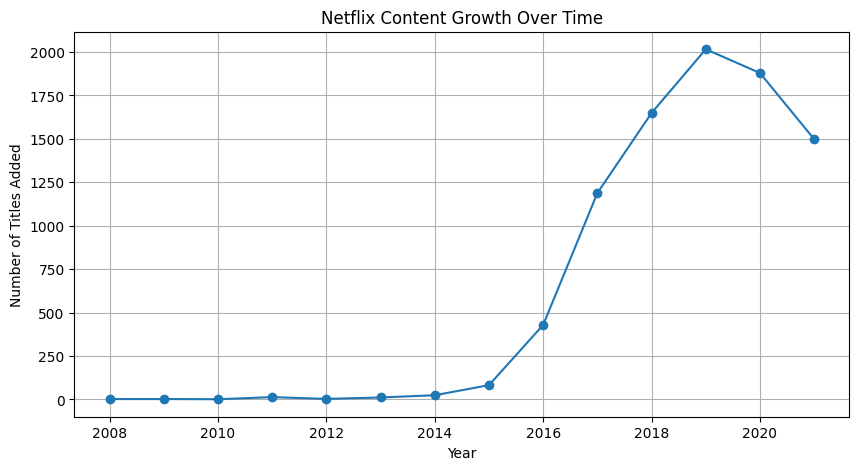

In [101]:
plt.figure(figsize=(10,5))
content_growth.plot(kind='line', marker='o')
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid(True)

plt.show()

# Task 2: Visualize the distribution of genres, ratings, and content type.

In [104]:
df['type'].value_counts()

type
Movie      6131
Tv Show    2676
Name: count, dtype: int64

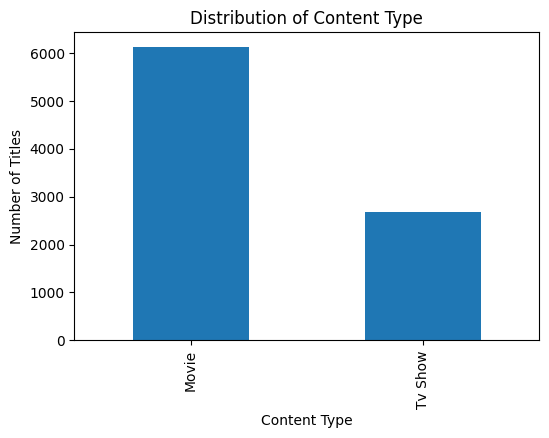

In [106]:
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar')
plt.title("Distribution of Content Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [108]:
df['rating'].value_counts()

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
NOT RATED       4
NC-17           3
UR              3
66 MIN          1
74 MIN          1
84 MIN          1
Name: count, dtype: int64

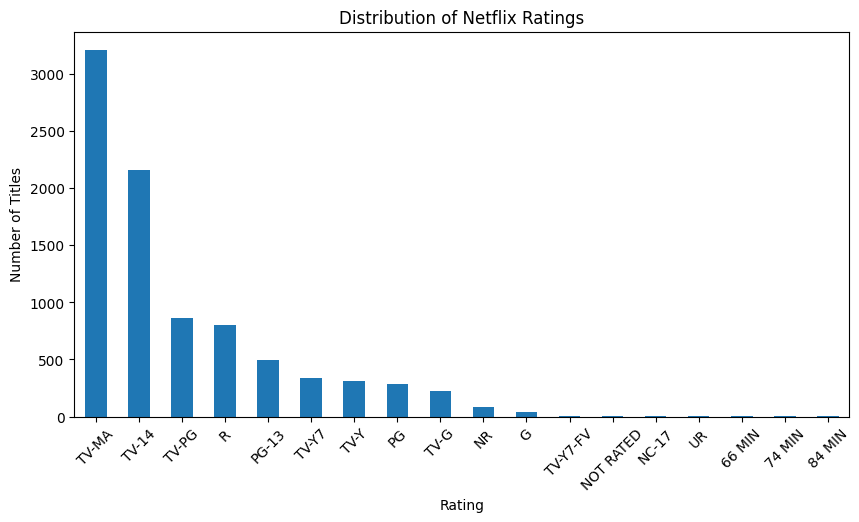

In [110]:
plt.figure(figsize=(10,5))
df['rating'].value_counts().plot(kind='bar')
plt.title("Distribution of Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [114]:
genres = df['listed_in'].str.split(', ').explode()

In [116]:
top_genres = genres.value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International Tv Shows      1351
Documentaries                869
Action & Adventure           859
Tv Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

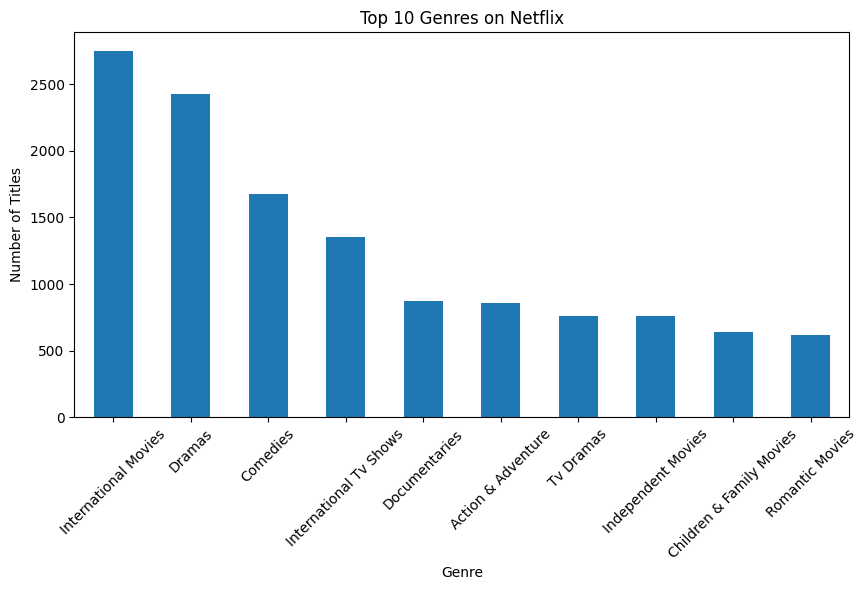

In [118]:
plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

# Task 3: Identify country-level content contributions.

In [123]:
df['country'].head()

0    United States
1     South Africa
2    Not Available
3    Not Available
4            India
Name: country, dtype: object

In [125]:
countries = df['country'].str.split(', ').explode()

In [127]:
country_counts = countries.value_counts()
top_countries = country_counts.head(10)
top_countries

country
United States     3689
India             1046
Not Available      831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

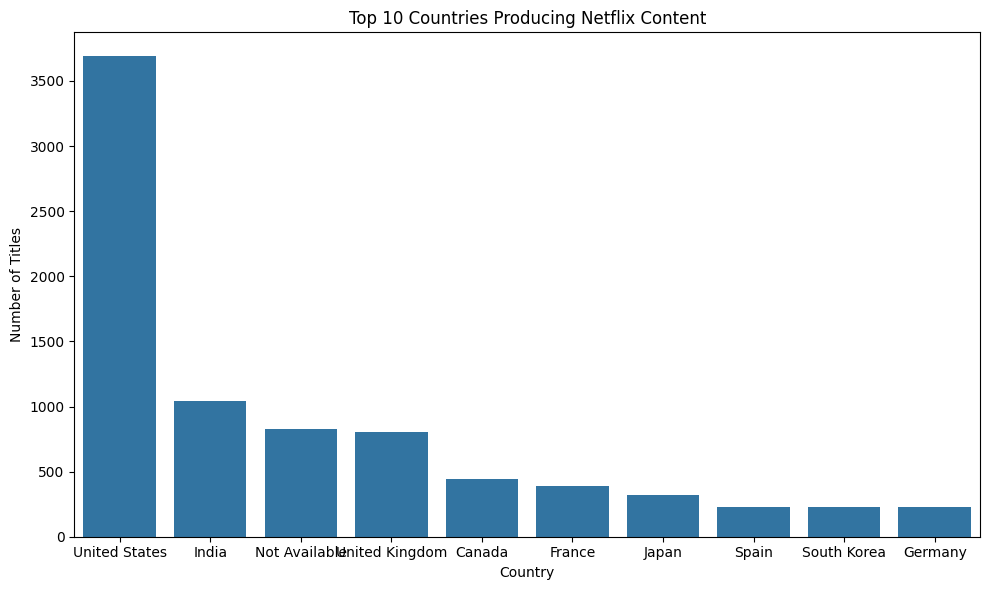

In [129]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.tight_layout()

plt.show()

# Task 4: Create derived features such as “Content Length Category” and “Original vs Licensed”.

In [135]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [137]:
def length_category(row):
    if row['type'] == 'Movie':
        if row['duration_num'] <= 60:
            return "Short Movie"
        elif row['duration_num'] <= 120:
            return "Medium Movie"
        else:
            return "Long Movie"
    else:
        if row['duration_num'] <= 1:
            return "Single Season Show"
        else:
            return "Multi Season Show"

In [139]:
df['content_length_category'] = df.apply(length_category, axis=1)

In [141]:
df[['type','duration','duration_num','content_length_category']].head()

,type,duration,duration_num,content_length_category
0,Movie,90 min,90.0,Medium Movie
1,Tv Show,2 seasons,2.0,Multi Season Show
2,Tv Show,1 season,1.0,Single Season Show
3,Tv Show,1 season,1.0,Single Season Show
4,Tv Show,2 seasons,2.0,Multi Season Show


In [143]:
length_counts = df['content_length_category'].value_counts()

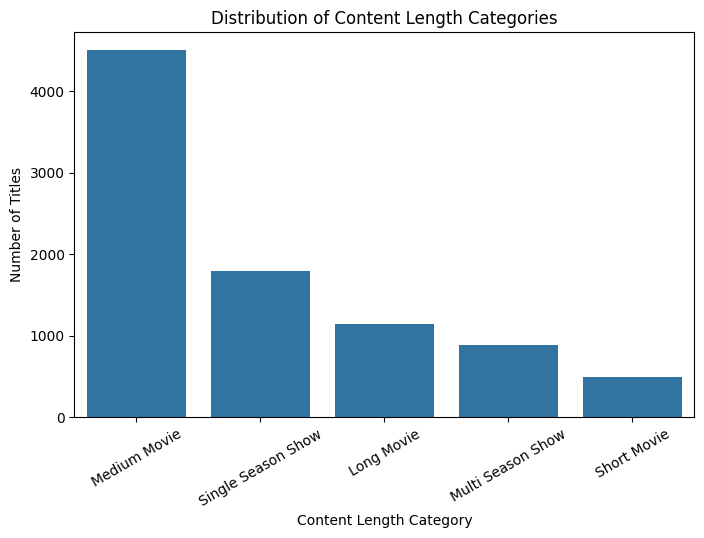

In [145]:
plt.figure(figsize=(8,5))
sns.barplot(x=length_counts.index, y=length_counts.values)
plt.title("Distribution of Content Length Categories")
plt.xlabel("Content Length Category")
plt.ylabel("Number of Titles")
plt.xticks(rotation=30)

plt.show()

In [147]:
df['year_added'] = df['date_added'].dt.year

def determine_originality(row):

    if pd.isna(row['year_added']):
        return 'Unknown'
    if row['release_year'].year == row['year_added']:
        return 'Original'
    else:
        return 'Licensed'

df['original_vs_licensed'] = df.apply(determine_originality, axis=1)

print(df['original_vs_licensed'].value_counts())

original_vs_licensed
Licensed    5556
Original    3241
Unknown       10
Name: count, dtype: int64


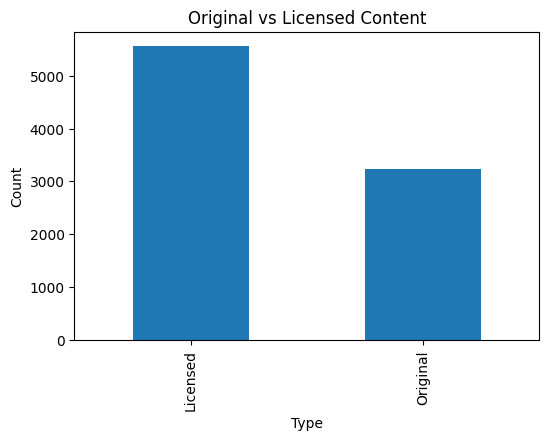

In [165]:
import matplotlib.pyplot as plt

counts = df['original_vs_licensed'].value_counts()

# Remove Unknown
counts = counts.drop('Unknown', errors='ignore')

plt.figure(figsize=(6,4))
counts.plot(kind='bar')

plt.title('Original vs Licensed Content')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

In [163]:
df[['title','original_vs_licensed']].head()

,title,original_vs_licensed
0,Dick Johnson Is Dead,Licensed
1,Blood & Water,Original
2,Ganglands,Original
3,Jailbirds New Orleans,Original
4,Kota Factory,Original
